# A causal temporal role GNN

This studybook builds the first graph neural network whose information set is correct **at each invoice's own prediction time**. It assumes notebook `05`'s two-clock idea, p90 maturity rule, and strictly-prior histories, but it assumes no prior knowledge of temporal GNNs. We will derive the messages, inspect their tensors, train without using test labels for model selection, and compare five fixed seeds with the causal LightGBM bar.

The goal is evidence, not a forced GNN win: a useful experiment may show where message passing helps, where it fails, and what should change next.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from graph_ml.baselines import (
    build_point_in_time_feature_frame,
    fit_point_in_time_encoder,
    point_in_time_cold_start_mask,
    transform_point_in_time_instruments,
)
from graph_ml.data import TEMPORAL_RELATIONS, build_temporal_relation_context
from graph_ml.evaluation import (
    RollingOriginFoldSpec,
    build_horizon_label_availability,
    build_point_in_time_fold,
)
from graph_ml.training import (
    TemporalGNNTrainingConfig,
    evaluate_temporal_gnn_run,
    fit_temporal_role_gnn,
)
from graph_ml.viz import (
    plot_seed_variability,
    plot_temporal_decay_curve,
    plot_temporal_message_schematic,
    plot_training_history,
    seed_metric_summary,
)

ROOT = next(path for path in (Path.cwd(), *Path.cwd().parents) if (path / 'pyproject.toml').exists())
DATA = ROOT / 'data'

## 1. From a static graph to an event-time graph

A static graph asks, “which invoices share a company?” A temporal graph adds, “which of those invoices already existed when this invoice arrived?” For a current invoice $i$ at time $t_i$, an older invoice $j$ is a legal neighbour only if $t_j < t_i$. A future invoice and a simultaneous invoice are both excluded.

The company remains the bridge, but we materialize its state as a causal summary of earlier invoice events. This prevents a current or future row from changing the representation used for today's decision.

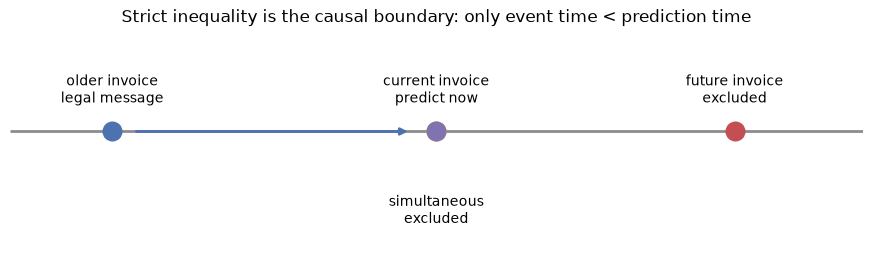

In [2]:
fig, ax = plt.subplots(figsize=(11, 2.8))
ax.hlines(0, 0, 10, color='0.55', linewidth=2)
events = [(1.2, 'older invoice\nlegal message', '#4C72B0'), (5, 'current invoice\npredict now', '#F0A202'), (5, 'simultaneous\nexcluded', '#8172B2'), (8.5, 'future invoice\nexcluded', '#C44E52')]
offsets = [0.18, 0.18, -0.46, 0.18]
for (x, label, color), y in zip(events, offsets):
    ax.scatter(x, 0, s=180, color=color, zorder=3)
    ax.text(x, y, label, ha='center', va='bottom' if y > 0 else 'top')
ax.annotate('', xy=(4.7, 0), xytext=(1.45, 0), arrowprops={'arrowstyle': '-|>', 'color': '#4C72B0', 'lw': 2})
ax.set(xlim=(0, 10), ylim=(-0.85, 0.75), title='Strict inequality is the causal boundary: only event time < prediction time')
ax.axis('off')
plt.show()

## 2. Four channels preserve business roles

The current seller and buyer can each have appeared historically in either role. Collapsing those appearances would confuse “money this company sold” with “money this company owed.” We therefore use four relation channels. Each channel gets its own learned transformation.

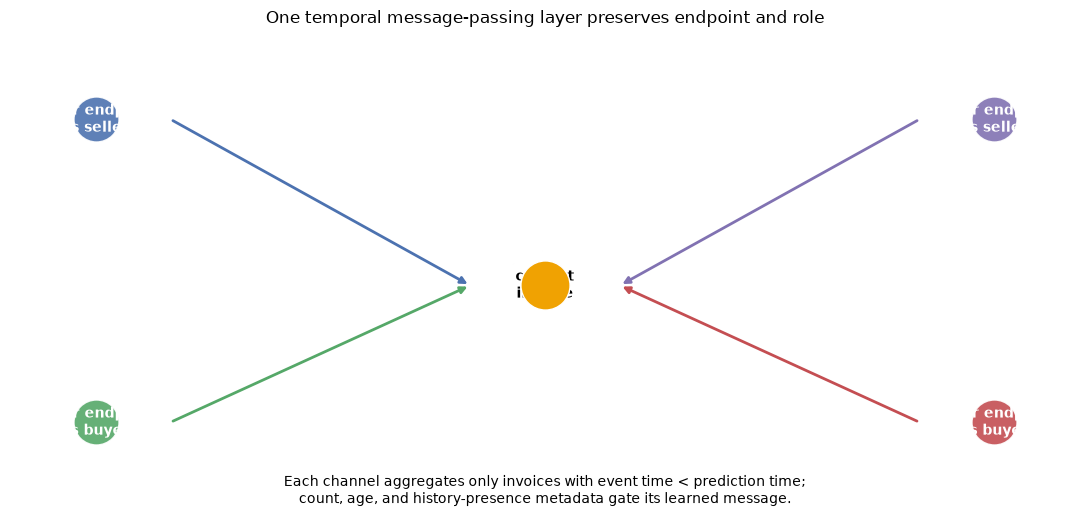

,relation index,channel
0,0,seller_endpoint__seller_role
1,1,seller_endpoint__buyer_role
2,2,buyer_endpoint__seller_role
3,3,buyer_endpoint__buyer_role


In [3]:
plot_temporal_message_schematic()
plt.show()
pd.DataFrame({'relation index': range(4), 'channel': TEMPORAL_RELATIONS})

## 3. Recency is part of the message

Not every past invoice should count equally. For age $\Delta t=t_i-t_j$, this model uses exponential weight

$$w_{ij}=\exp(-\log(2)\,\Delta t/H),$$

where $H=180$ days is the frozen half-life. An event 180 days old has half the weight of a just-arrived event; 360 days old has one quarter. This is an explicit inductive bias, not a claim that 180 days is economically optimal. Changing it requires validation-only experiments.

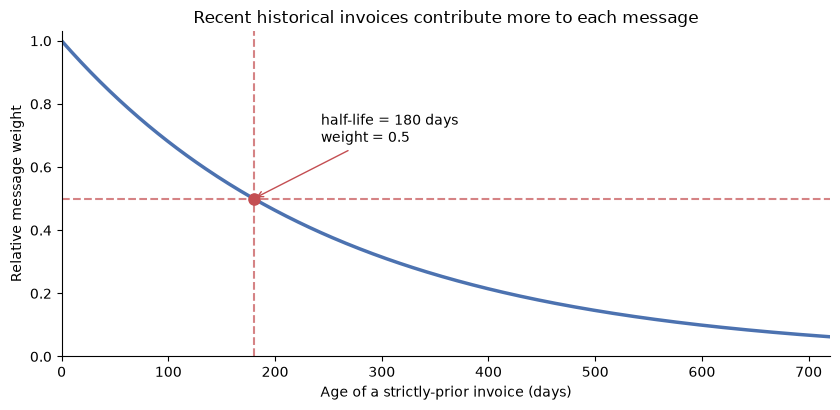

In [4]:
plot_temporal_decay_curve(half_life_days=180)
plt.show()

For relation $r$, the causal context is the weighted mean

$$c_{i,r}=\frac{\sum_{j:t_j<t_i} w_{ij}x_j}{\sum_{j:t_j<t_i}w_{ij}}.$$

The model also receives $m_{i,r}=[\log(1+n),\log(1+\text{age}),\mathbb{1}(n>0)]$: how much history exists, how old the latest event is, and whether history exists at all. A learned gate can then reduce or reshape a message whose evidence is sparse or stale.

## 4. Inspect the real tensors before training

The feature encoder is fitted only on labels/features available before the deployment cutoff. The context builder may process the full event table efficiently, but every query uses a strict prefix: later rows never enter an earlier row's context. The tensors have shapes `[invoices, features]`, `[invoices, four relations, features]`, and `[invoices, four relations, three metadata values]`.

In [5]:
instruments = pd.read_parquet(DATA / '02_instrumentsdf_2.parquet')
availability = build_horizon_label_availability(instruments, target_column='is_pastdue90', horizon_days=90)
fold = build_point_in_time_fold(
    instruments['invoice_date'],
    availability,
    RollingOriginFoldSpec('2017-08-01', '2018-04-30', '2018-12-19'),
)
features = build_point_in_time_feature_frame(instruments)
encoder = fit_point_in_time_encoder(features, fold.refit_mask)
instrument_values, feature_names = transform_point_in_time_instruments(features, encoder)
context = build_temporal_relation_context(instruments, instrument_values, half_life_days=180)

pd.DataFrame({
    'tensor': ['current invoice', 'causal relation context', 'relation metadata'],
    'shape': [str(instrument_values.shape), str(context.values.shape), str(context.metadata.shape)],
    'meaning of last axis': [f'{len(feature_names)} origination features', f'{len(feature_names)} decayed feature means', 'log-count, log-age, has-history'],
})

,tensor,shape,meaning of last axis
0,current invoice,"(59820, 12)",12 origination features
1,causal relation context,"(59820, 4, 12)",12 decayed feature means
2,relation metadata,"(59820, 4, 3)","log-count, log-age, has-history"


History coverage matters because the model cannot invent a track record for a genuinely new endpoint. The next chart shows the fraction of test invoices with at least one earlier event in each channel. Cold-start is defined at the deployment cutoff, while strict history is evaluated at each invoice time; those are related but not identical concepts.

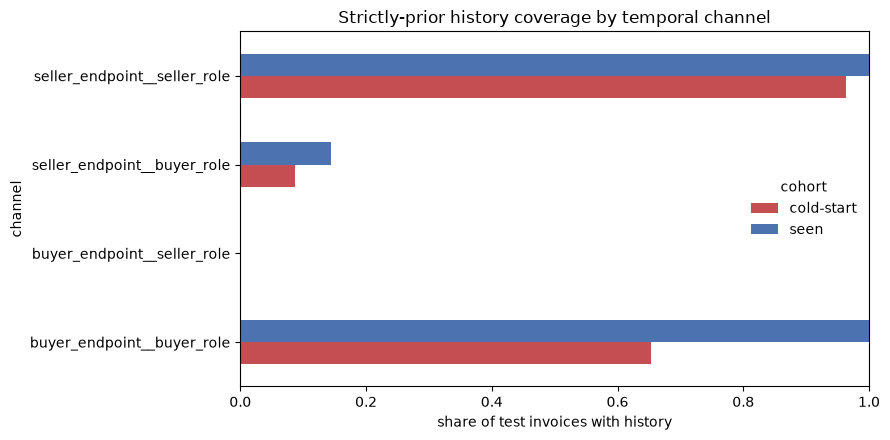

In [6]:
cold = point_in_time_cold_start_mask(instruments, cutoff='2018-04-30')
coverage_rows = []
for cohort, mask in [('seen', fold.test_mask & ~cold), ('cold-start', fold.test_mask & cold)]:
    for relation, name in enumerate(TEMPORAL_RELATIONS):
        coverage_rows.append({'cohort': cohort, 'channel': name, 'history coverage': context.metadata[mask, relation, 2].mean()})
coverage = pd.DataFrame(coverage_rows)
pivot = coverage.pivot(index='channel', columns='cohort', values='history coverage')
ax = pivot.plot.barh(figsize=(9, 4.5), color=['#C44E52', '#4C72B0'])
ax.set(title='Strictly-prior history coverage by temporal channel', xlabel='share of test invoices with history', xlim=(0, 1))
ax.legend(title='cohort', frameon=False)
plt.tight_layout(); plt.show()

## 5. The learned update

The current invoice keeps a direct **root** path, so graph context cannot erase its own attributes. Each relation contributes a transformed context plus transformed time metadata, controlled by a learned gate:

$$h_i=\operatorname{Root}(x_i)+\sum_r \sigma(G_rm_{i,r})\odot[W_rc_{i,r}+U_rm_{i,r}].$$

Layer normalization, ReLU, dropout, and a residual refinement block follow; a final linear layer emits the p90 logit. This has 10,177 parameters. It is a temporal bipartite message-passing layer with pre-aggregated causal events—not yet a recurrent company-memory model such as TGN.

## 6. Training without spending the test set

The early window selects the number of epochs using rolling validation PR-AUC. A fresh model is then trained for exactly that many epochs on all labels known before 2018-04-30. Only after selection and refitting do we score the held-out period. Class weighting addresses imbalance; deterministic CPU execution makes a seed reproducible.

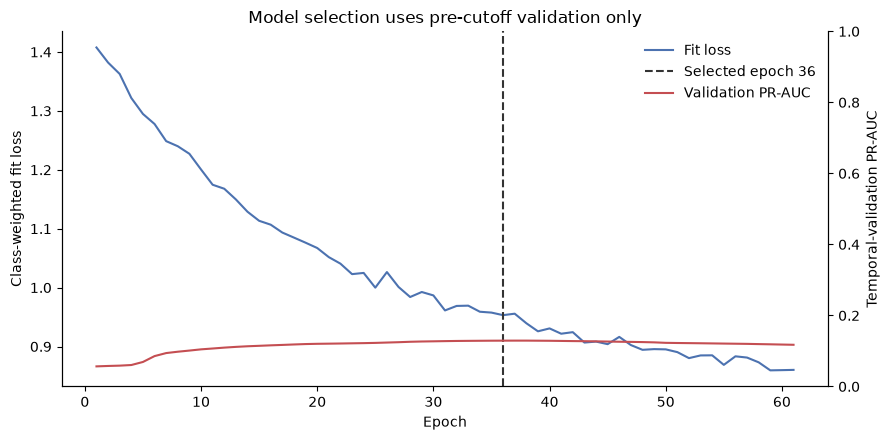

selected epoch: 36; best validation PR-AUC: 0.129; parameters: 10,177


In [7]:
run = fit_temporal_role_gnn(
    instruments, features, availability, fold, TemporalGNNTrainingConfig(seed=42)
)
plot_training_history(
    run.search_train_losses,
    run.search_validation_pr_aucs,
    best_epoch=run.best_epoch,
)
plt.show()
print(f'selected epoch: {run.best_epoch}; best validation PR-AUC: {run.best_validation_pr_auc:.3f}; parameters: {run.parameter_count:,}')

In [8]:
seed_42_metrics = evaluate_temporal_gnn_run(
    run, availability,
    {'test_all': fold.test_mask, 'test_seen': fold.test_mask & ~cold, 'test_cold_start': fold.test_mask & cold},
)
seed_42_metrics.style.format({'prevalence': '{:.2%}', 'pr_auc': '{:.3f}', 'roc_auc': '{:.3f}', 'precision_at_k': '{:.2%}', 'recall_at_k': '{:.2%}'})

,model,cohort,review_fraction,sample_count,positive_count,prevalence,pr_auc,roc_auc,top_k,precision_at_k,recall_at_k
0,temporal_role_gnn,test_all,0.050000,10554,222,2.10%,0.034,0.657,528,0.57%,1.35%
1,temporal_role_gnn,test_seen,0.050000,8119,166,2.04%,0.041,0.696,406,0.49%,1.20%
2,temporal_role_gnn,test_cold_start,0.050000,2435,56,2.30%,0.025,0.546,122,0.82%,1.79%


## 7. One seed is not a result

Neural optimization depends on initialization. Five seeds use the **same frozen configuration**; no hyperparameter was changed after looking at the held-out period. Diamonds mark the GNN mean and stars mark the single deterministic LightGBM benchmark. A lucky maximum is useful for diagnosing capacity, but it is not the number we should advertise.

,cohort,run_count,mean,sample_std,minimum,maximum
0,test_all,5,0.053,0.033,0.023,0.105
1,test_seen,5,0.065,0.044,0.024,0.135
2,test_cold_start,5,0.023,0.003,0.019,0.027


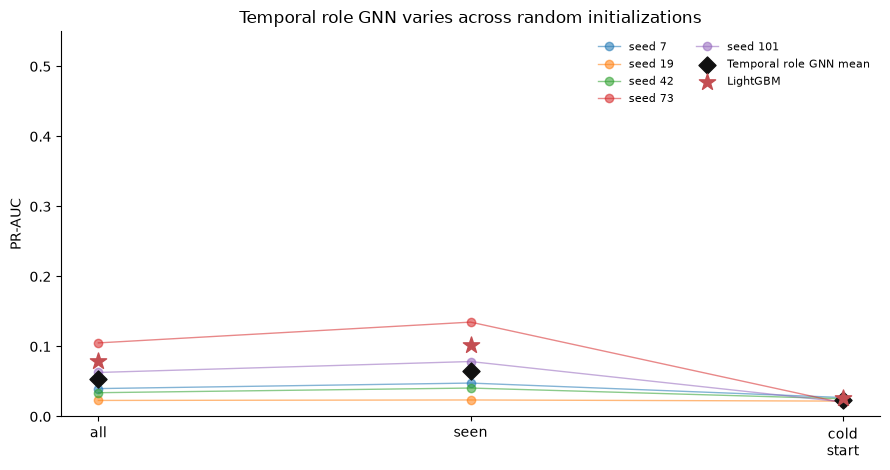

In [9]:
seed_metrics = pd.read_csv(ROOT / 'results' / 'temporal_gnn_p90_metrics.csv')
summary = seed_metric_summary(seed_metrics)
display(summary.style.format({'mean': '{:.3f}', 'sample_std': '{:.3f}', 'minimum': '{:.3f}', 'maximum': '{:.3f}'}))
plot_seed_variability(
    seed_metrics,
    benchmark_pr_auc={'test_all': 0.079154149, 'test_seen': 0.102475877, 'test_cold_start': 0.026480200},
    model_label='Temporal role GNN',
)
plt.show()

The five-seed mean PR-AUC is **0.053 ± 0.033 overall**, **0.065 ± 0.044 on seen companies**, and **0.023 ± 0.003 on cold-start**. LightGBM scores 0.079, 0.102, and 0.026 respectively. Seed 73 reaches 0.105 overall and 0.135 seen, but selecting that seed after seeing test performance would be test leakage. The distribution—not its maximum—is the evidence.

Cold-start is the clearest failure: performance stays tightly around its 0.023 prevalence and four seeds retrieve no cold-start positives in the top 5%. Temporal history helps only when history exists; a better cold-start strategy needs stronger current-invoice features, transferable company descriptors, or training objectives that do not depend so heavily on endpoint history.

## 8. Does the graph context add anything?

A **root-only control** removes all four relation messages while keeping the nonlinear root, normalization, residual refinement, loss, rolling selection, and five-seed reporting. It has 5,313 parameters versus 10,177, and answers a narrower question than LightGBM: does causal graph history improve this neural family beyond the current invoice alone? This control was predeclared before its result was run; it is a diagnostic, not a new model selected from test performance.

,family,cohort,mean,std
0,temporal relation messages,test_all,0.053,0.033
1,temporal relation messages,test_seen,0.065,0.044
2,temporal relation messages,test_cold_start,0.023,0.003
3,root only,test_all,0.035,0.001
4,root only,test_seen,0.038,0.002
5,root only,test_cold_start,0.033,0.004


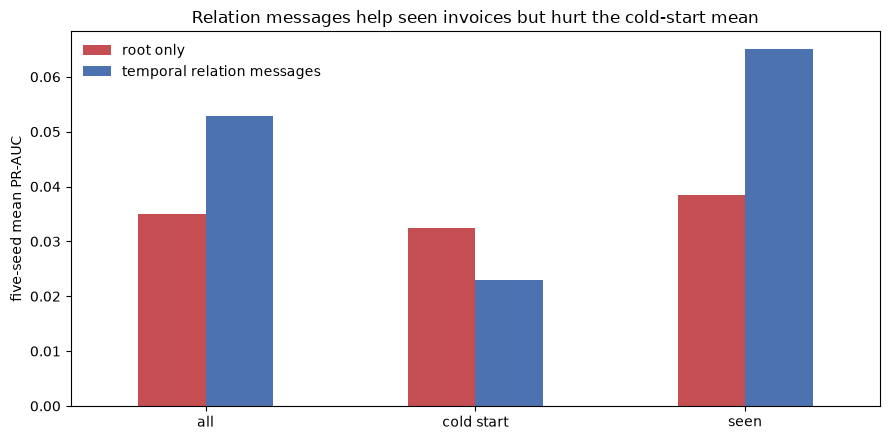

In [10]:
root_metrics = pd.read_csv(ROOT / 'results' / 'root_only_p90_metrics.csv')
comparison = pd.concat([
    seed_metrics.assign(family='temporal relation messages'),
    root_metrics.assign(family='root only'),
]).groupby(['family', 'cohort'], sort=False)['pr_auc'].agg(['mean', 'std']).reset_index()
display(comparison.style.format({'mean': '{:.3f}', 'std': '{:.3f}'}))
pivot = comparison.pivot(index='cohort', columns='family', values='mean')
ax = pivot.plot.bar(figsize=(9, 4.5), color=['#C44E52', '#4C72B0'])
ax.set(title='Relation messages help seen invoices but hurt the cold-start mean', ylabel='five-seed mean PR-AUC', xlabel='')
ax.set_xticklabels([label.get_text().replace('test_', '').replace('_', ' ') for label in ax.get_xticklabels()], rotation=0)
ax.legend(title='', frameon=False)
plt.tight_layout(); plt.show()

The root-only mean is **0.035 overall**, **0.038 seen**, and **0.033 cold-start**, with much less seed variation than the full model. Relation messages raise overall/seen means to 0.053/0.065, so they contain useful signal where endpoint history exists. But they lower cold-start from 0.033 to 0.023. The likely mechanism is not mysterious: zero or sparse contexts still pass learned metadata messages and gates trained mostly on history-rich rows. The next validation-only change should therefore improve history-aware fallback/gating before adding depth.

## What this experiment does—and does not—establish

**Established:** features and messages obey strict event time; p90 labels obey due-date-plus-90 maturity at every fold boundary; preprocessing and epoch selection stay inside the rolling training/validation window; the GNN and LightGBM use identical cohorts; multiple seeds expose instability.

**Not established:** that 180 days is the best decay; that weighted means are the best aggregator; that one message layer captures longer hybrid-mediated contagion; or that the current data can support causal impairment prediction. Those require validation-only ablations and verified event sources—not repeated choices against this test period.

## Takeaways

1. A temporal GNN is not merely a static GNN plus a date feature: its neighborhood itself must be restricted to events with $t_j<t_i$.
2. Four channels preserve both endpoint and historical role, while decay and metadata express recency and evidence volume.
3. The first causal temporal role GNN is not robustly stronger than causal LightGBM: mean PR-AUC is 0.053 versus 0.079 overall.
4. A single strong seed would give the wrong conclusion. Five-seed variability is now part of the minimum neural reporting contract.
5. The root-only control confirms that relation messages help seen-history ranking but hurt cold-start. Next, improve the empty-history fallback using validation folds, then test relation collapse, predeclared decay choices, and recent-neighbour attention. Keep the test period sealed while choosing among them.